In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Q2 - House Price Prediction Using Linear Regression

In [54]:
# Load Training & Testing Data
train_data = pd.read_csv("q2train.csv")
test_data = pd.read_csv("q2test.csv")

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

print("\nTraining Data:")
display(train_data.head())

print("\nTesting Data:")
display(test_data.head())

Training data shape: (13603, 4)
Testing data shape: (6700, 4)

Training Data:


,price,bedrooms,living_in_m2,real_bathrooms
0,312000,2,138.42547,2
1,310000,2,105.90942,1
2,320000,2,117.98681,1
3,264500,2,151.43189,2
4,700000,3,341.88304,3



Testing Data:


,price,bedrooms,living_in_m2,real_bathrooms
0,305000,2,76.18046,1
1,498000,3,210.88981,2
2,590000,2,262.91549,2
3,775000,3,159.79316,1
4,350000,2,92.90300,1


In [55]:
# Separate Features and Target
features = ["bedrooms", "living_in_m2", "real_bathrooms"]

X_train, y_train = train_data[features], train_data["price"]
X_test, y_test = test_data[features], test_data["price"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTraining Features:")
display(X_train.head())

print("\nTraining Target:")
display(y_train.head())

X_train shape: (13603, 3)
y_train shape: (13603,)

Training Features:


,bedrooms,living_in_m2,real_bathrooms
0,2,138.42547,2
1,2,105.90942,1
2,2,117.98681,1
3,2,151.43189,2
4,3,341.88304,3



Training Target:


,price
0,312000
1,310000
2,320000
3,264500
4,700000


In [56]:
# Feature Scaling
X_mean, X_std = X_train.mean(), X_train.std()

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

print("Training Feature Mean:")
display(X_mean)

print("\nTraining Feature Standard Deviation:")
display(X_std)

print("\nScaled Training Data:")
display(X_train_scaled.head())

Training Feature Mean:


,0
bedrooms,2.238624
living_in_m2,181.746181
real_bathrooms,1.678968



Training Feature Standard Deviation:


,0
bedrooms,0.682151
living_in_m2,67.917214
real_bathrooms,0.627218



Scaled Training Data:


,bedrooms,living_in_m2,real_bathrooms
0,-0.349811,-0.637846,0.511835
1,-0.349811,-1.116606,-1.082508
2,-0.349811,-0.938781,-1.082508
3,-0.349811,-0.446342,0.511835
4,1.116139,2.357824,2.106178


In [57]:
# Prepare Matrices for Gradient Descent
X_gd = np.c_[
    np.ones(len(X_train_scaled)),
    X_train_scaled.to_numpy()
]

X_test_gd = np.c_[
    np.ones(len(X_test_scaled)),
    X_test_scaled.to_numpy()
]

y_gd = y_train.to_numpy()

m = len(y_gd)

print("X_gd shape:", X_gd.shape)
print("X_test_gd shape:", X_test_gd.shape)
print("Number of training examples (m):", m)

print("\nFirst 5 rows of X_gd:")
print(X_gd[:5])

X_gd shape: (13603, 4)
X_test_gd shape: (6700, 4)
Number of training examples (m): 13603

First 5 rows of X_gd:
[[ 1.         -0.34981063 -0.63784581  0.51183534]
 [ 1.         -0.34981063 -1.11660588 -1.08250771]
 [ 1.         -0.34981063 -0.93878071 -1.08250771]
 [ 1.         -0.34981063 -0.44634178  0.51183534]
 [ 1.          1.11613947  2.35782432  2.10617838]]


In [58]:
# Gradient Descent Function
def gradient_descent(X, y, alpha, iterations):
    theta = np.zeros(X.shape[1])
    cost_history = []

    for _ in range(iterations):
        error = X @ theta - y

        cost_history.append(
            (1 / (2 * m)) * np.sum(error ** 2)
        )

        theta = theta - alpha * (1 / m) * (X.T @ error)

    return theta, cost_history

print("Gradient Descent function created successfully.")

Gradient Descent function created successfully.


In [59]:
# Train Gradient Descent Model
theta, cost_history = gradient_descent(
    X_gd,
    y_gd,
    alpha=0.1,
    iterations=2000
)

print("Gradient Descent Results")
print("Theta:", theta)
print("Initial Cost:", cost_history[0])
print("Final Cost:", cost_history[-1])

Gradient Descent Results
Theta: [475286.09034772 -24011.33607608 137353.7247737    6810.10559685]
Initial Cost: 134438310122.39546
Final Cost: 13215167967.16469


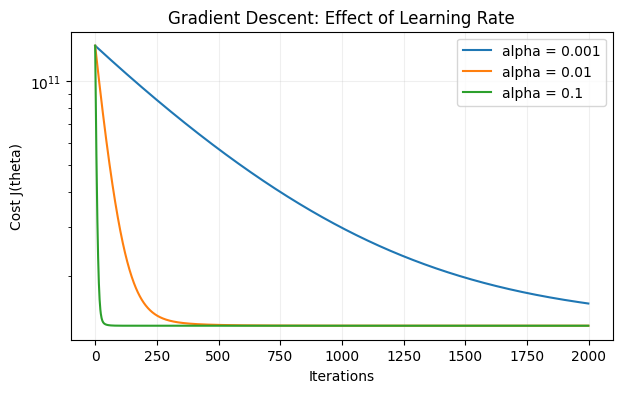

In [60]:
# Learning Rate Comparison Graph
plt.figure(figsize=(7, 4))

for a in [0.001, 0.01, 0.1]:
    _, hist = gradient_descent(
        X_gd,
        y_gd,
        alpha=a,
        iterations=2000
    )

    plt.plot(hist, label=f"alpha = {a}")

plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel("Cost J(theta)")
plt.title("Gradient Descent: Effect of Learning Rate")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [61]:
# Gradient Descent Test Performance
y_pred_gd = X_test_gd @ theta

mse_gd = mean_squared_error(y_test, y_pred_gd)
rmse_gd = np.sqrt(mse_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("Gradient Descent Test Performance")
print("---------------------------------")
print("MSE:", mse_gd)
print("RMSE:", rmse_gd)
print("R² Score:", r2_gd)

print("\nFirst 5 Predictions:")
results_gd = pd.DataFrame({
    "Actual Price": y_test.iloc[:5].values,
    "Predicted Price": y_pred_gd[:5]
})

display(results_gd)

Gradient Descent Test Performance
---------------------------------
MSE: 26690568587.087734
RMSE: 163372.48417982672
R² Score: 0.3832662401179463

First 5 Predictions:


,Actual Price,Predicted Price
0,305000,262820.590904
1,498000,510910.940117
2,590000,651325.526126
3,775000,396716.972304
4,350000,296639.751270


In [62]:
# Normal Equation
X_ne = np.c_[
    np.ones(len(X_train)),
    X_train.to_numpy()
]

X_test_ne = np.c_[
    np.ones(len(X_test)),
    X_test.to_numpy()
]

theta_ne = np.linalg.solve(
    X_ne.T @ X_ne,
    X_ne.T @ y_gd
)

print("Normal Equation Results")
print("Theta:", theta_ne)

Normal Equation Results
Theta: [168296.7233972  -35199.4204272    2022.36982931  10857.64447461]


In [63]:
# Normal Equation Test Performance
y_pred_ne = X_test_ne @ theta_ne

mse_ne = mean_squared_error(y_test, y_pred_ne)
rmse_ne = np.sqrt(mse_ne)
r2_ne = r2_score(y_test, y_pred_ne)

print("Normal Equation Test Performance")
print("MSE:", mse_ne)
print("RMSE:", rmse_ne)
print("R² Score:", r2_ne)

print("\nFirst 5 Predictions:")
results_ne = pd.DataFrame({
    "Actual Price": y_test.iloc[:5].values,
    "Predicted Price": y_pred_ne[:5]
})

display(results_ne)

Normal Equation Test Performance
MSE: 26690568587.08773
RMSE: 163372.48417982672
R² Score: 0.3832662401179464

First 5 Predictions:


,Actual Price,Predicted Price
0,305000,262820.590904
1,498000,510910.940117
2,590000,651325.526126
3,775000,396716.972304
4,350000,296639.751270


In [64]:
# Check GD vs Normal Equation Parameters Fairly
theta_ne_scaled = np.linalg.solve(
    X_gd.T @ X_gd,
    X_gd.T @ y_gd
)

theta_difference = np.max(
    np.abs(theta - theta_ne_scaled)
)

print("Gradient Descent theta:")
print(theta)

print("\nNormal Equation theta (scaled space):")
print(theta_ne_scaled)

print("\nMaximum theta difference:")
print(theta_difference)

Gradient Descent theta:
[475286.09034772 -24011.33607608 137353.7247737    6810.10559685]

Normal Equation theta (scaled space):
[475286.09034772 -24011.33607608 137353.7247737    6810.10559685]

Maximum theta difference:
2.6193447411060333e-10


In [65]:
# Mean Baseline
y_pred_base = np.full(
    len(y_test),
    y_train.mean()
)

mse_b = mean_squared_error(y_test, y_pred_base)
rmse_b = np.sqrt(mse_b)
r2_b = r2_score(y_test, y_pred_base)

print("Mean Baseline Performance")
print("Mean Training Price:", y_train.mean())
print("MSE:", mse_b)
print("RMSE:", rmse_b)
print("R² Score:", r2_b)

Mean Baseline Performance
Mean Training Price: 475286.0903477174
MSE: 43277310476.65472
RMSE: 208031.99387751566
R² Score: -3.679487940999593e-07


In [66]:
# Final Comparison Table
comparison = pd.DataFrame({
    "Method": [
        "Gradient Descent",
        "Normal Equation",
        "Mean Baseline"
    ],
    "MSE": [
        mse_gd,
        mse_ne,
        mse_b
    ],
    "RMSE": [
        rmse_gd,
        rmse_ne,
        rmse_b
    ],
    "R² Score": [
        r2_gd,
        r2_ne,
        r2_b
    ]
})

print("Final Model Comparison")
display(comparison)

Final Model Comparison


,Method,MSE,RMSE,R² Score
0,Gradient Descent,2.669057e+10,163372.484180,3.832662e-01
1,Normal Equation,2.669057e+10,163372.484180,3.832662e-01
2,Mean Baseline,4.327731e+10,208031.993878,-3.679488e-07


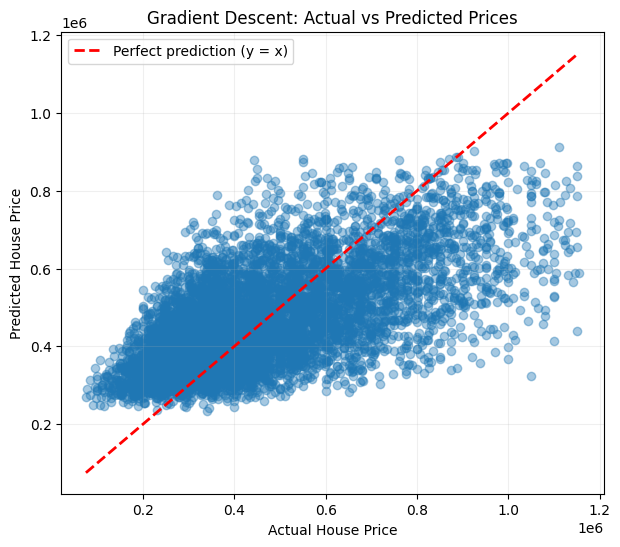

In [67]:
# Actual vs Predicted Graph
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred_gd,
    alpha=0.4
)

lo = min(
    y_test.min(),
    y_pred_gd.min()
)

hi = max(
    y_test.max(),
    y_pred_gd.max()
)

plt.plot(
    [lo, hi],
    [lo, hi],
    "--",
    linewidth=2,
    color="red",
    label="Perfect prediction (y = x)"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Gradient Descent: Actual vs Predicted Prices")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

# Q3 - Polynomial Interpolation and Regression

In [81]:
velocity = np.array([0, 2, 4, 6, 8, 10], dtype=float)
force = np.array([0, 2.90, 14.8, 39.6, 74.3, 119], dtype=float)

print("Velocity (100 ft/s):", velocity)
print("Force (100 lb):", force)

Velocity (100 ft/s): [ 0.  2.  4.  6.  8. 10.]
Force (100 lb): [  0.    2.9  14.8  39.6  74.3 119. ]


In [82]:
x_new = 750 / 100

print("750 ft/s in given data units =", x_new)

750 ft/s in given data units = 7.5


In [83]:
V = np.vander(velocity, 6, increasing=True)

print("Interpolation Matrix:")
print(V)

print("\nMatrix Rank:", np.linalg.matrix_rank(V))

Interpolation Matrix:
[[1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.0000e+00 2.0000e+00 4.0000e+00 8.0000e+00 1.6000e+01 3.2000e+01]
 [1.0000e+00 4.0000e+00 1.6000e+01 6.4000e+01 2.5600e+02 1.0240e+03]
 [1.0000e+00 6.0000e+00 3.6000e+01 2.1600e+02 1.2960e+03 7.7760e+03]
 [1.0000e+00 8.0000e+00 6.4000e+01 5.1200e+02 4.0960e+03 3.2768e+04]
 [1.0000e+00 1.0000e+01 1.0000e+02 1.0000e+03 1.0000e+04 1.0000e+05]]

Matrix Rank: 6


In [84]:
c_int = np.linalg.solve(V, force)

print("Interpolating Coefficients:")
print(c_int)

Interpolating Coefficients:
[ 0.          1.7125     -1.19479167  0.66145833 -0.07005208  0.00260417]


In [85]:
interpolation_errors = V @ c_int - force

print("Interpolation Errors:")
print(interpolation_errors)

Interpolation Errors:
[0.00000000e+00 8.43769499e-15 4.26325641e-14 3.55271368e-14
 9.94759830e-14 5.68434189e-14]


In [86]:
def poly_eval(c, x):
    return sum(c[i] * x**i for i in range(len(c)))

print("Polynomial evaluation function created successfully.")

Polynomial evaluation function created successfully.


In [87]:
p_int = poly_eval(c_int, x_new)

print("Interpolation Estimate")
print("Force (100 lb):", round(p_int, 4))
print("Force (lb):", round(p_int * 100, 2))

Interpolation Estimate
Force (100 lb): 64.8384
Force (lb): 6483.84


In [88]:
A = np.vander(velocity, 3, increasing=True)

print("Quadratic Regression Matrix:")
print(A)

print("\nMatrix Shape:", A.shape)

Quadratic Regression Matrix:
[[  1.   0.   0.]
 [  1.   2.   4.]
 [  1.   4.  16.]
 [  1.   6.  36.]
 [  1.   8.  64.]
 [  1.  10. 100.]]

Matrix Shape: (6, 3)


In [89]:
c_quad = np.linalg.solve(
    A.T @ A,
    A.T @ force
)

print("Quadratic Regression Coefficients:")
print(c_quad)

Quadratic Regression Coefficients:
[ 0.06428571 -1.4875      1.34017857]


In [90]:
residuals = A @ c_quad - force

sse = np.sum(residuals ** 2)

print("Regression Residuals:")
print(residuals)

print("\nSum of Squared Errors:", sse)

Regression Residuals:
[ 0.06428571 -0.45        0.75714286 -0.21428571 -0.36428571  0.20714286]

Sum of Squared Errors: 1.001428571428569


In [91]:
p_quad = poly_eval(c_quad, x_new)

print("Quadratic Regression Estimate")
print("Force (100 lb):", round(p_quad, 4))
print("Force (lb):", round(p_quad * 100, 2))

Quadratic Regression Estimate
Force (100 lb): 64.2931
Force (lb): 6429.31


In [92]:
numpy_coefficients = np.polyfit(
    velocity,
    force,
    2
)[::-1]

print("Our coefficients:")
print(c_quad)

print("\nNumPy coefficients:")
print(numpy_coefficients)

print("\nDo they match?")
print(np.allclose(c_quad, numpy_coefficients))

Our coefficients:
[ 0.06428571 -1.4875      1.34017857]

NumPy coefficients:
[ 0.06428571 -1.4875      1.34017857]

Do they match?
True


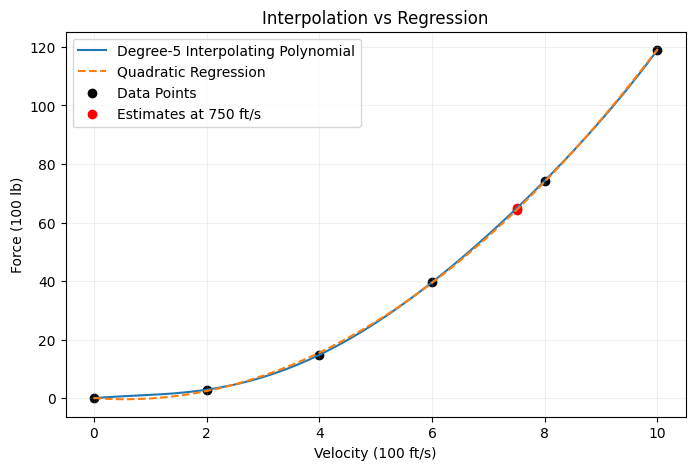

In [93]:
xs = np.linspace(0, 10, 200)

plt.figure(figsize=(8, 5))

plt.plot(
    xs,
    poly_eval(c_int, xs),
    label="Degree-5 Interpolating Polynomial"
)

plt.plot(
    xs,
    poly_eval(c_quad, xs),
    "--",
    label="Quadratic Regression"
)

plt.scatter(
    velocity,
    force,
    color="black",
    label="Data Points"
)

plt.scatter(
    [x_new, x_new],
    [p_int, p_quad],
    color="red",
    label="Estimates at 750 ft/s"
)

plt.xlabel("Velocity (100 ft/s)")
plt.ylabel("Force (100 lb)")
plt.title("Interpolation vs Regression")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [94]:
print("Final Results")

print(
    f"Interpolation: {p_int:.3f} (x100 lb) = {p_int*100:,.2f} lb"
)

print(
    f"Regression:    {p_quad:.3f} (x100 lb) = {p_quad*100:,.2f} lb"
)

difference = abs(p_int - p_quad)

print(
    f"Difference:    {difference:.3f} (x100 lb) = {difference*100:,.2f} lb"
)

Final Results
Interpolation: 64.838 (x100 lb) = 6,483.84 lb
Regression:    64.293 (x100 lb) = 6,429.31 lb
Difference:    0.545 (x100 lb) = 54.53 lb


### Difference Between Interpolation and Regression

Interpolation constructs a polynomial that passes exactly through all the given data points. Therefore, the residual error at the observed points is approximately zero. In this problem, six data points are used to construct a fifth-degree interpolating polynomial.

Regression does not necessarily pass through every data point. Instead, it finds a polynomial that provides the best overall fit by minimizing the sum of squared errors. Here, a quadratic polynomial is fitted to the six observations.

At 750 ft/s, the interpolating polynomial estimates the force as approximately 6483.84 lb, while quadratic regression estimates approximately 6429.31 lb.

# Q4 - Logistic Regression Classification

In [97]:
# Load Training and Testing Data
train_data = pd.read_csv("q4trainlr.csv")
test_data = pd.read_csv("q4testlr.csv")

print("Training Data Shape:", train_data.shape)
print("Testing Data Shape:", test_data.shape)

print("\nTraining Data:")
display(train_data.head())

print("\nTesting Data:")
display(test_data.head())

Training Data Shape: (80, 3)
Testing Data Shape: (20, 3)

Training Data:


,x1,x2,class
0,0.129440,0.14356,0
1,-0.060081,0.18525,0
2,-0.046083,0.36888,1
3,0.010081,0.20041,0
4,-0.044758,0.16076,0



Testing Data:


,x1,x2,class
0,0.17396,0.26676,1
1,-0.82431,-0.72668,0
2,-0.89355,-0.47638,0
3,-0.89908,-0.40292,0
4,-0.71935,-0.10904,0


In [98]:
# Separate Features and Target
features = ["x1", "x2"]

X_train = train_data[features]
y_train = train_data["class"]

X_test = test_data[features]
y_test = test_data["class"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTraining Features:")
display(X_train.head())

print("\nTraining Classes:")
display(y_train.head())

X_train shape: (80, 2)
y_train shape: (80,)

Training Features:


,x1,x2
0,0.129440,0.14356
1,-0.060081,0.18525
2,-0.046083,0.36888
3,0.010081,0.20041
4,-0.044758,0.16076



Training Classes:


,class
0,0
1,0
2,1
3,0
4,0


In [99]:
# Train Linear Logistic Regression
linear_model = LogisticRegression()

linear_model.fit(X_train, y_train)

print("Linear Logistic Regression trained successfully.")

print("\nIntercept:")
print(linear_model.intercept_)

print("\nCoefficients:")
print(linear_model.coef_)

Linear Logistic Regression trained successfully.

Intercept:
[-0.64412976]

Coefficients:
[[-0.36539581  2.5703261 ]]


In [100]:
# Linear Model Predictions
y_pred_linear = linear_model.predict(X_test)

results_linear = pd.DataFrame({
    "Actual Class": y_test.values,
    "Predicted Class": y_pred_linear
})

print("Linear Model Predictions:")
display(results_linear)

Linear Model Predictions:


,Actual Class,Predicted Class
0,1,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,1,0
7,1,0
8,1,0
9,1,1


In [101]:
# Linear Model Performance
accuracy_linear = accuracy_score(
    y_test,
    y_pred_linear
)

cm_linear = confusion_matrix(
    y_test,
    y_pred_linear
)

print("Linear Logistic Regression Performance")

print("Accuracy:", accuracy_linear)

print("\nConfusion Matrix:")
print(cm_linear)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_linear
    )
)

Linear Logistic Regression Performance
Accuracy: 0.75

Confusion Matrix:
[[12  0]
 [ 5  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83        12
           1       1.00      0.38      0.55         8

    accuracy                           0.75        20
   macro avg       0.85      0.69      0.69        20
weighted avg       0.82      0.75      0.71        20



In [102]:
# Create Polynomial Features
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train)

X_test_poly = poly.transform(X_test)

print("Original number of features:", X_train.shape[1])
print("Polynomial number of features:", X_train_poly.shape[1])

print("\nPolynomial Features:")
print(poly.get_feature_names_out(features))

Original number of features: 2
Polynomial number of features: 5

Polynomial Features:
['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']


In [103]:
# Train Non-Linear Logistic Regression
nonlinear_model = LogisticRegression(
    max_iter=5000
)

nonlinear_model.fit(
    X_train_poly,
    y_train
)

print("Non-Linear Logistic Regression trained successfully.")

print("\nIntercept:")
print(nonlinear_model.intercept_)

print("\nCoefficients:")
print(nonlinear_model.coef_)

Non-Linear Logistic Regression trained successfully.

Intercept:
[-0.71562592]

Coefficients:
[[-0.32652007  2.44400551  0.25552159 -0.09866603  1.31567563]]


In [104]:
# Non-Linear Model Predictions
y_pred_nonlinear = nonlinear_model.predict(
    X_test_poly
)

results_nonlinear = pd.DataFrame({
    "Actual Class": y_test.values,
    "Predicted Class": y_pred_nonlinear
})

print("Non-Linear Model Predictions:")
display(results_nonlinear)

Non-Linear Model Predictions:


,Actual Class,Predicted Class
0,1,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,1,0
7,1,0
8,1,0
9,1,1


In [105]:
# Non-Linear Model Performance
accuracy_nonlinear = accuracy_score(
    y_test,
    y_pred_nonlinear
)

cm_nonlinear = confusion_matrix(
    y_test,
    y_pred_nonlinear
)

print("Non-Linear Logistic Regression Performance")

print("Accuracy:", accuracy_nonlinear)

print("\nConfusion Matrix:")
print(cm_nonlinear)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_nonlinear
    )
)

Non-Linear Logistic Regression Performance
Accuracy: 0.75

Confusion Matrix:
[[12  0]
 [ 5  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83        12
           1       1.00      0.38      0.55         8

    accuracy                           0.75        20
   macro avg       0.85      0.69      0.69        20
weighted avg       0.82      0.75      0.71        20



In [122]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(model, X_tr, X_te):
    out = {}
    for split, X, y in [("Train", X_tr, y_train), ("Test", X_te, y_test)]:
        p = model.predict(X)
        out[f"{split} Accuracy"] = accuracy_score(y, p)
        if split == "Test":
            out["Test Precision (class 1)"] = precision_score(y, p)
            out["Test Recall (class 1)"] = recall_score(y, p)
            out["Test F1 (class 1)"] = f1_score(y, p)
    return out

comparison = pd.DataFrame({
    "Linear Decision Boundary": evaluate(linear_model, X_train, X_test),
    "Non-Linear Decision Boundary": evaluate(nonlinear_model, X_train_poly, X_test_poly),
}).T.round(3)

display(comparison)
print("\n\nBoth models have the same confusion matrix on the test set: 12 true negatives, 0 false positives, 5 false negatives, 3 true positives.")

,Train Accuracy,Test Accuracy,Test Precision (class 1),Test Recall (class 1),Test F1 (class 1)
Linear Decision Boundary,0.912,0.75,1.0,0.375,0.545
Non-Linear Decision Boundary,0.900,0.75,1.0,0.375,0.545




Both models have the same confusion matrix on the test set: 12 true negatives, 0 false positives, 5 false negatives, 3 true positives.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


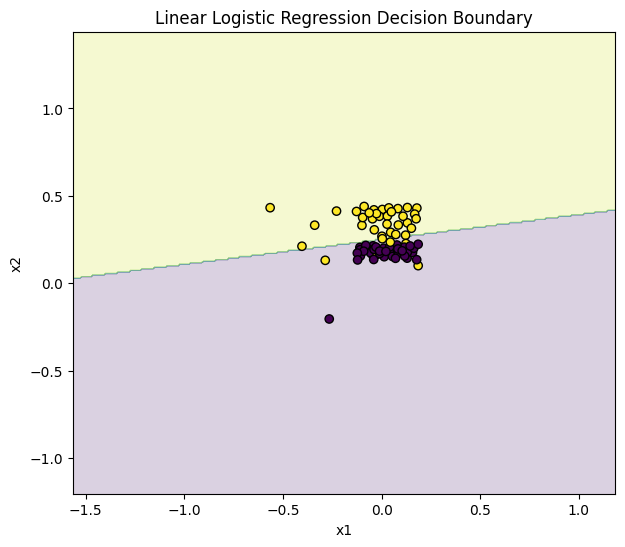

In [116]:
# Linear Decision Boundary Graph
x1_min = X_train["x1"].min() - 1
x1_max = X_train["x1"].max() + 1

x2_min = X_train["x2"].min() - 1
x2_max = X_train["x2"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = linear_model.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2
)

plt.scatter(
    X_train["x1"],
    X_train["x2"],
    c=y_train,
    edgecolors="black"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Linear Logistic Regression Decision Boundary")

plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


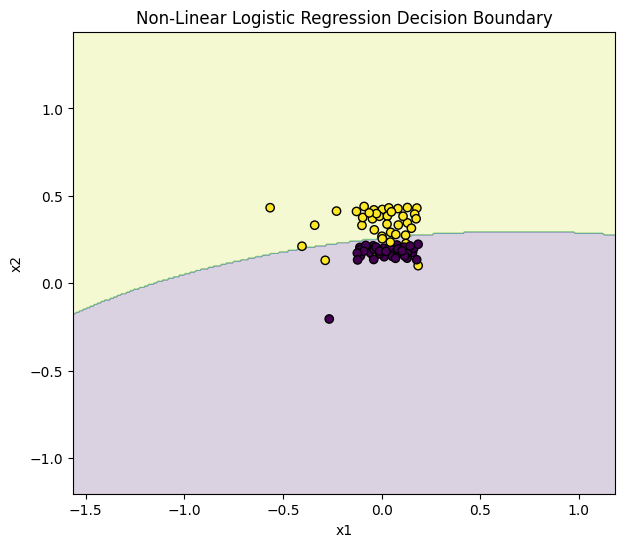

In [117]:
# Non-Linear Decision Boundary Graph
grid_poly = poly.transform(grid)

Z_poly = nonlinear_model.predict(grid_poly)
Z_poly = Z_poly.reshape(xx.shape)

plt.figure(figsize=(7, 6))

plt.contourf(
    xx,
    yy,
    Z_poly,
    alpha=0.2
)

plt.scatter(
    X_train["x1"],
    X_train["x2"],
    c=y_train,
    edgecolors="black"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Non-Linear Logistic Regression Decision Boundary")

plt.show()

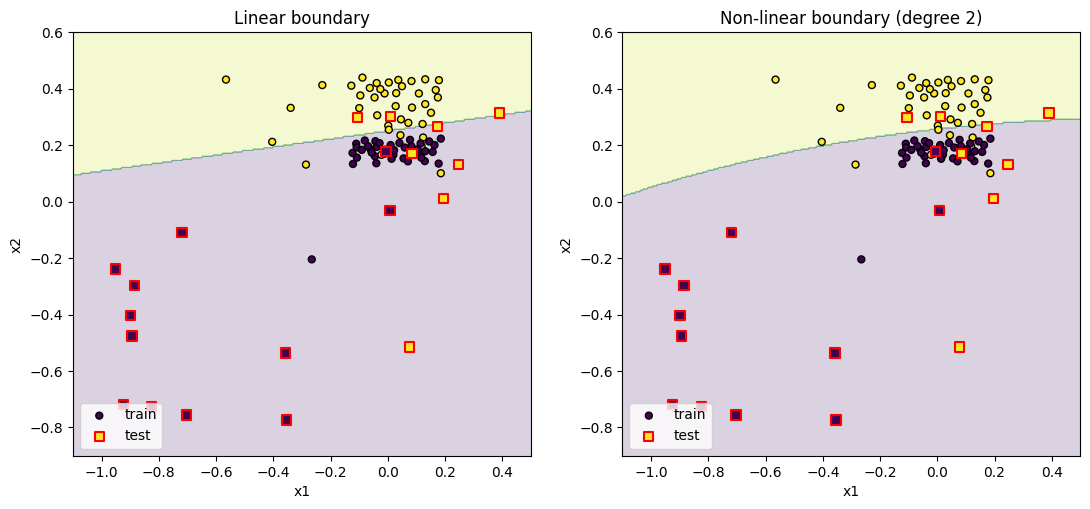

In [114]:
xx, yy = np.meshgrid(np.linspace(-1.1, 0.5, 300), np.linspace(-0.9, 0.6, 300))
grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=features)

def plot_boundary(ax, predict_fn, title):
    Z = predict_fn(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2)
    ax.scatter(X_train["x1"], X_train["x2"], c=y_train, marker="o",
               edgecolors="black", s=25, label="train")
    ax.scatter(X_test["x1"], X_test["x2"], c=y_test, marker="s",
               edgecolors="red", s=45, linewidths=1.5, label="test")
    ax.set(title=title, xlabel="x1", ylabel="x2")
    ax.legend(loc="lower left")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_boundary(axes[0], lambda g: linear_model.predict(g), "Linear boundary")
plot_boundary(axes[1], lambda g: nonlinear_model.predict(poly.transform(g)),
              "Non-linear boundary (degree 2)")
plt.show()

In [115]:
for C in [1, 10, 100, 10000]:
    lin = LogisticRegression(C=C, max_iter=100000).fit(X_train, y_train)
    non = LogisticRegression(C=C, max_iter=100000).fit(X_train_poly, y_train)
    print(f"C={C:>6}: linear test acc = {lin.score(X_test, y_test):.2f} | "
          f"non-linear test acc = {non.score(X_test_poly, y_test):.2f}")

C=     1: linear test acc = 0.75 | non-linear test acc = 0.75
C=    10: linear test acc = 0.80 | non-linear test acc = 0.80
C=   100: linear test acc = 0.80 | non-linear test acc = 0.75
C= 10000: linear test acc = 0.80 | non-linear test acc = 0.40


### Additional Analysis of Regularization

Both models reach the same best test accuracy of 0.80 at C = 10, so the non-linear decision boundary provides no clear performance advantage on this dataset.

However, the models differ in their sensitivity to the regularization parameter. The linear model maintains a test accuracy of 0.80 for C ≥ 10, while the non-linear model decreases from 0.80 at C = 10 to 0.75 at C = 100 and 0.40 at C = 10,000. This suggests that the more flexible polynomial model becomes less robust as regularization is weakened.

With the default C = 1, both models achieve 0.75 test accuracy and show the same classification performance. Since the test set contains only 20 observations, small differences in the number of correctly classified samples can noticeably affect the reported accuracy.

Overall, the linear model is preferable for this dataset because it is simpler, achieves the same best test accuracy, and is less sensitive to changes in the regularization parameter.